## Characterization of the experimental groups

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# Constants
BARRELS_PER_TONNE = 7.33
TONNES_PER_MT = 1_000_000

In [2]:
MSCI_EM_constituent_list = [ "Brazil", "Chile", "China", "Colombia", "Czechia", "Egypt",
                             "Greece", "Hungary", "India", "Indonesia", "South Korea", "Kuwait", 
                             "Malaysia", "Mexico", "Peru", "Philippines", "Poland", "Qatar",
                            "Saudi Arabia", "South Africa", "Taiwan", "Thailand", "Turkey", "United Arab Emirates"]

MSCI_EM_constituent_list_clean = [ "Brazil", "Chile", "China", "Colombia", "Czechia", "Egypt",
                             "Greece", "Hungary", "India", "Indonesia", "South Korea", "Kuwait", 
                             "Malaysia", "Mexico", "Peru", "Philippines", "Poland", "Qatar",
                            "Saudi Arabia", "South Africa", "Taiwan", "Thailand", "Turkey", "Abu Dhabi", "Dubai"] #Length: 24

### Valid CDS data

In [3]:
CDS_df = pd.read_csv('data/processed/CDS/Weekly_CDS.csv')
CDS_df['Date'] = pd.to_datetime(CDS_df['Date'])
CDS_df.set_index('Date', inplace=True)

CDS_df = CDS_df[CDS_df.index >= datetime.datetime(2014,1,1)].copy()
CDS_df = CDS_df[[col for col in CDS_df.columns if col in MSCI_EM_constituent_list_clean]]

cds_stats = []

for country in CDS_df.columns:
    # Get the time series for this country (drop NaN values)
    series = CDS_df[country].dropna()
    
    if len(series) > 0:
        # Start date
        start_date = series.index[0]
        
        # Calculate returns (percentage change from one row to next)
        returns = series.diff()
        
        # Count zero returns (where consecutive values are the same)
        zero_returns = (returns == 0).sum()
        
        # Percentage of zero returns
        total_returns = len(returns) - 1  # Exclude the first NaN from diff()
        pct_zero_returns = (zero_returns / total_returns * 100) if total_returns > 0 else 0
        
        cds_stats.append({
            'Country': country,
            'Series Start': start_date,
            'Observations': len(series),
            'Zero Returns (%)': round(pct_zero_returns, 2),
            'Decision': "Keep" if pct_zero_returns < 5 else "Discard"
        })

# Create and display the statistics table
cds_stats_df = pd.DataFrame(cds_stats).sort_values('Country')
print(cds_stats_df.to_string(index=False))
print(f"\nTotal countries: {len(cds_stats_df)}")



     Country Series Start  Observations  Zero Returns (%) Decision
   Abu Dhabi   2014-01-03           574              1.92     Keep
      Brazil   2014-01-03           574              0.35     Keep
       Chile   2014-01-03           574              0.52     Keep
       China   2014-01-03           574              1.57     Keep
    Colombia   2014-01-03           574              0.00     Keep
     Czechia   2014-01-03           574             16.58  Discard
       Dubai   2014-01-03           574              6.46  Discard
       Egypt   2014-01-03           574              1.40     Keep
      Greece   2014-01-03           574             25.13  Discard
     Hungary   2014-01-03           574              4.36     Keep
       India   2015-03-27           510             41.65  Discard
   Indonesia   2014-01-03           574              0.87     Keep
      Kuwait   2017-06-16           394             32.32  Discard
    Malaysia   2014-01-03           574              1.57     

In [4]:
# Crude oil balance (need to handle apostrophe thousands separator)
crude_oil_balance = pd.read_csv('data/processed/Oil/crude_oil_trade_balance.csv', 
                                 thousands="'")
crude_oil_balance.set_index('Country', inplace=True)

crude_filtered = crude_oil_balance.loc[crude_oil_balance.index.isin(MSCI_EM_constituent_list)]

crude_filtered = crude_filtered.T
crude_filtered.index = crude_filtered.index.astype(int)

# Oil prices
annual_oil_price = pd.read_csv('data/processed/Oil/Annual_avg_price_of_oil_macrotrends.csv')
annual_oil_price['Year'] = pd.to_datetime(annual_oil_price['Date']).dt.year
oil_prices = annual_oil_price.set_index('Year')['Value']

In [5]:
# -----------------------------------------------------------------------------
# CONVERT MT TO USD BILLIONS
# -----------------------------------------------------------------------------

# After loading and filtering crude oil balance, convert to numeric
crude_filtered = crude_filtered.apply(pd.to_numeric, errors='coerce')

crude_oil_usd = crude_filtered.copy()
# Then do the conversion
for year in crude_oil_usd.index:
    if year in oil_prices.index:
        price = oil_prices[year]
        crude_oil_usd.loc[year] = crude_filtered.loc[year] * TONNES_PER_MT * BARRELS_PER_TONNE * price / 1e9

In [6]:
# -----------------------------------------------------------------------------
# PREPARE GDP (map country names and convert to billions)
# -----------------------------------------------------------------------------

# GDP (long format)
IMFWEO_data = pd.read_csv('data/processed/Macroeconomic_variables/IMF_WEO_full_annual_data.csv', delimiter=';')

#Filter selected columns
gdp_filtered = IMFWEO_data[IMFWEO_data['INDICATOR'] == 'Gross domestic product (GDP) - Current prices - US dollar'].drop(columns=['INDICATOR','FREQUENCY','SCALE'])

#Set index
gdp_filtered.set_index('COUNTRY',inplace=True)

# Filter to selected countries
gdp_filtered = gdp_filtered.loc[gdp_filtered.index.isin(MSCI_EM_constituent_list)]

# Transpose: index = years, columns = countries
gdp_transposed = gdp_filtered.T
gdp_transposed.index = gdp_transposed.index.astype(int)

#gdp_transposed
gdp_transposed.head()

COUNTRY,Greece,Turkey,South Africa,Colombia,Brazil,Chile,Mexico,Peru,Kuwait,Qatar,...,Indonesia,Taiwan,Malaysia,South Korea,India,Philippines,Thailand,China,Hungary,Poland
2000,127.438,273.570,151.855,99.270,655.454,78.250,742.061,50.414,37.714,18.085,...,179.482,330.680,102.149,597.802,468.396,83.667,126.392,1220.337,47.276,172.151
2001,132.051,203.001,135.527,97.606,559.982,71.517,796.055,51.034,34.906,17.498,...,174.507,299.276,101.054,567.655,485.440,78.921,120.296,1351.372,53.800,191.403
2002,150.148,238.674,129.385,97.353,509.798,70.295,810.666,53.954,38.129,19.334,...,212.807,307.439,109.833,649.747,514.938,84.307,134.301,1486.618,67.636,199.694
2003,196.881,317.342,197.017,94.072,558.232,76.508,765.550,58.537,47.869,23.716,...,255.346,317.381,120.025,728.497,607.701,87.039,152.281,1680.942,85.190,218.561
2004,234.873,408.309,256.188,116.382,669.290,99.079,819.459,66.126,59.439,30.651,...,279.344,346.924,135.869,822.583,709.152,95.002,172.896,1978.937,104.015,256.454


In [7]:
# -----------------------------------------------------------------------------
# CALCULATE OIL BALANCE AS % OF GDP
# -----------------------------------------------------------------------------

common_years = crude_oil_usd.index.intersection(gdp_transposed.index)
common_countries = crude_oil_usd.columns.intersection(gdp_transposed.columns)

print(f"\nCommon years: {common_years.min()} - {common_years.max()}")
print(f"Common countries: {list(common_countries)}")

crude_aligned = crude_oil_usd.loc[common_years, common_countries]
gdp_aligned = gdp_transposed.loc[common_years, common_countries]

oil_balance_pct_gdp = (crude_aligned / gdp_aligned) * 100


# -----------------------------------------------------------------------------
# SUMMARY TABLE
# -----------------------------------------------------------------------------
start_year = 2014
end_year = 2024

recent_years = [y for y in range(start_year, end_year + 1) if y in oil_balance_pct_gdp.index]
avg_balance = oil_balance_pct_gdp.loc[recent_years].mean().sort_values(ascending=True)  # ascending so exporters (negative) at top

print("\n" + "="*60)
print(f"AVERAGE CRUDE OIL TRADE BALANCE (% of GDP), {start_year}-{end_year}")
print("="*60)

for country in avg_balance.index:
    print(f"{country:20s}: {avg_balance[country]:+.2f}%")



Common years: 2000 - 2024
Common countries: ['Poland', 'Turkey', 'Brazil', 'Chile', 'Colombia', 'Mexico', 'China', 'India', 'Indonesia', 'Malaysia', 'Philippines', 'South Korea', 'Taiwan', 'Thailand', 'Egypt', 'South Africa', 'Kuwait', 'Qatar', 'Saudi Arabia', 'United Arab Emirates']

AVERAGE CRUDE OIL TRADE BALANCE (% of GDP), 2014-2024
Kuwait              : -30.93%
Saudi Arabia        : -18.03%
United Arab Emirates: -12.33%
Qatar               : -11.23%
Colombia            : -4.06%
Mexico              : -1.95%
Brazil              : -1.17%
Egypt               : -0.53%
Malaysia            : -0.46%
Indonesia           : +0.32%
Philippines         : +0.98%
Turkey              : +1.40%
Chile               : +1.44%
China               : +1.46%
South Africa        : +1.76%
Poland              : +1.95%
Taiwan              : +3.52%
India               : +3.70%
South Korea         : +3.79%
Thailand            : +4.48%


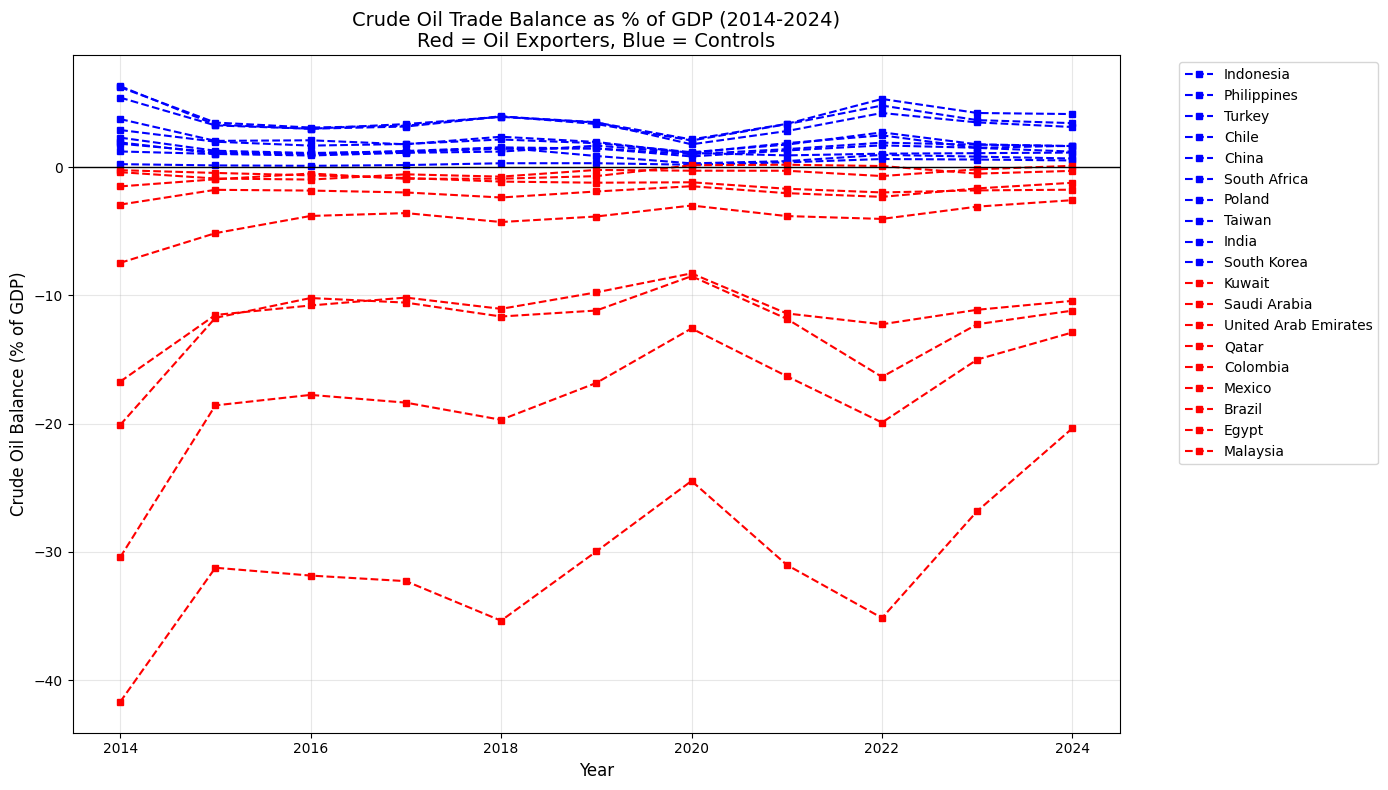

In [10]:
# -----------------------------------------------------------------------------
# PLOT
# -----------------------------------------------------------------------------

oil_exporters = ['Kuwait','Saudi Arabia', 'United Arab Emirates','Qatar','Colombia','Mexico','Brazil','Egypt','Malaysia']
controls = ['Indonesia','Philippines','Czechia','Turkey','Chile','China','South Africa',
            'Poland','Taiwan','India','South Korea','Tailand']

oil_balance_plot = oil_balance_pct_gdp.loc[start_year:end_year]

fig, ax = plt.subplots(figsize=(14, 8))

for country in controls:
    if country in oil_balance_plot.columns:
        ax.plot(oil_balance_plot.index, oil_balance_plot[country], 
                's--', color='blue', linewidth=1.5, markersize=4, label=country)
        
for country in oil_exporters:
    if country in oil_balance_plot.columns:
        ax.plot(oil_balance_plot.index, oil_balance_plot[country], 
                's--', color='red', linewidth=1.5, markersize=4, label=country)

ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Crude Oil Balance (% of GDP)', fontsize=12)
ax.set_title(f'Crude Oil Trade Balance as % of GDP ({start_year}-{end_year})\nRed = Oil Exporters, Blue = Controls', fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Proposed groups

In [11]:
oil_exporters = ['Saudi Arabia', 'United Arab Emirates','Qatar','Colombia','Mexico','Brazil','Egypt','Malaysia']
controls = ['Indonesia','Philippines','Turkey','Chile','China','South Africa','South Korea','Tailand'] 

benchmarks = ['Emerging Market and Developing Economies', 'World']


### Systematic Differences between groups that could lead to confounding?

- Geopolitical / Geography
- Credit Ratings
- GDP per Capita
- Debt to GDP
- Current Account
- 


In [12]:
all_countries = oil_exporters + controls + benchmarks

variables_of_interest = {
    'Gross debt - General government - Percent of GDP': 'Debt_GDP',
    'Current account balance (credit less debit) - Percent of GDP': 'CA_GDP',
    'Gross domestic product (GDP) - Current prices - Per capita - US dollar': 'GDP_pc',
    'Net lending (+) / net borrowing (-) - General government - Percent of GDP': 'Fiscal_Balance_GDP',
    'Gross national savings - Percent of GDP': 'Savings_GDP',
    'External debt - Percent of GDP': 'External_Debt_GDP',
}

def extract_variable(df, indicator_name, short_name):
    filtered = df[df['INDICATOR'] == indicator_name].drop(columns=['INDICATOR', 'FREQUENCY', 'SCALE'])
    filtered.set_index('COUNTRY', inplace=True)
    
    # Filter to selected countries
    available_countries = [c for c in all_countries if c in filtered.index]
    filtered = filtered.loc[filtered.index.isin(available_countries)]
    
    # Transpose: index = years, columns = countries
    transposed = filtered.T
    transposed.index = transposed.index.astype(int)
    transposed.columns.name = None
    
    return transposed

data_dict = {}
for indicator, short_name in variables_of_interest.items():
    try:
        data_dict[short_name] = extract_variable(IMFWEO_data, indicator, short_name)
        print(f"Extracted {short_name}: {data_dict[short_name].shape}")
    except Exception as e:
        print(f"Failed {short_name}: {e}")

Extracted Debt_GDP: (25, 16)
Extracted CA_GDP: (25, 16)
Extracted GDP_pc: (25, 15)
Extracted Fiscal_Balance_GDP: (25, 16)
Extracted Savings_GDP: (25, 17)
Extracted External_Debt_GDP: (25, 1)


In [13]:
year_range = range(2014, 2025)
plot_vars = ['Debt_GDP', 'CA_GDP', 'GDP_pc', 'Fiscal_Balance_GDP', 'Savings_GDP', 'External_Debt_GDP']
var_labels = {
    'Debt_GDP': 'Government Debt (% GDP)',
    'CA_GDP': 'Current Account (% GDP)', 
    'GDP_pc': 'GDP per Capita (USD)',
    'Fiscal_Balance_GDP': 'Fiscal Balance (% GDP)',
    'Savings_GDP': 'Gross National Savings (% GDP)',
    'External_Debt_GDP': 'External Debt (% GDP)',
}


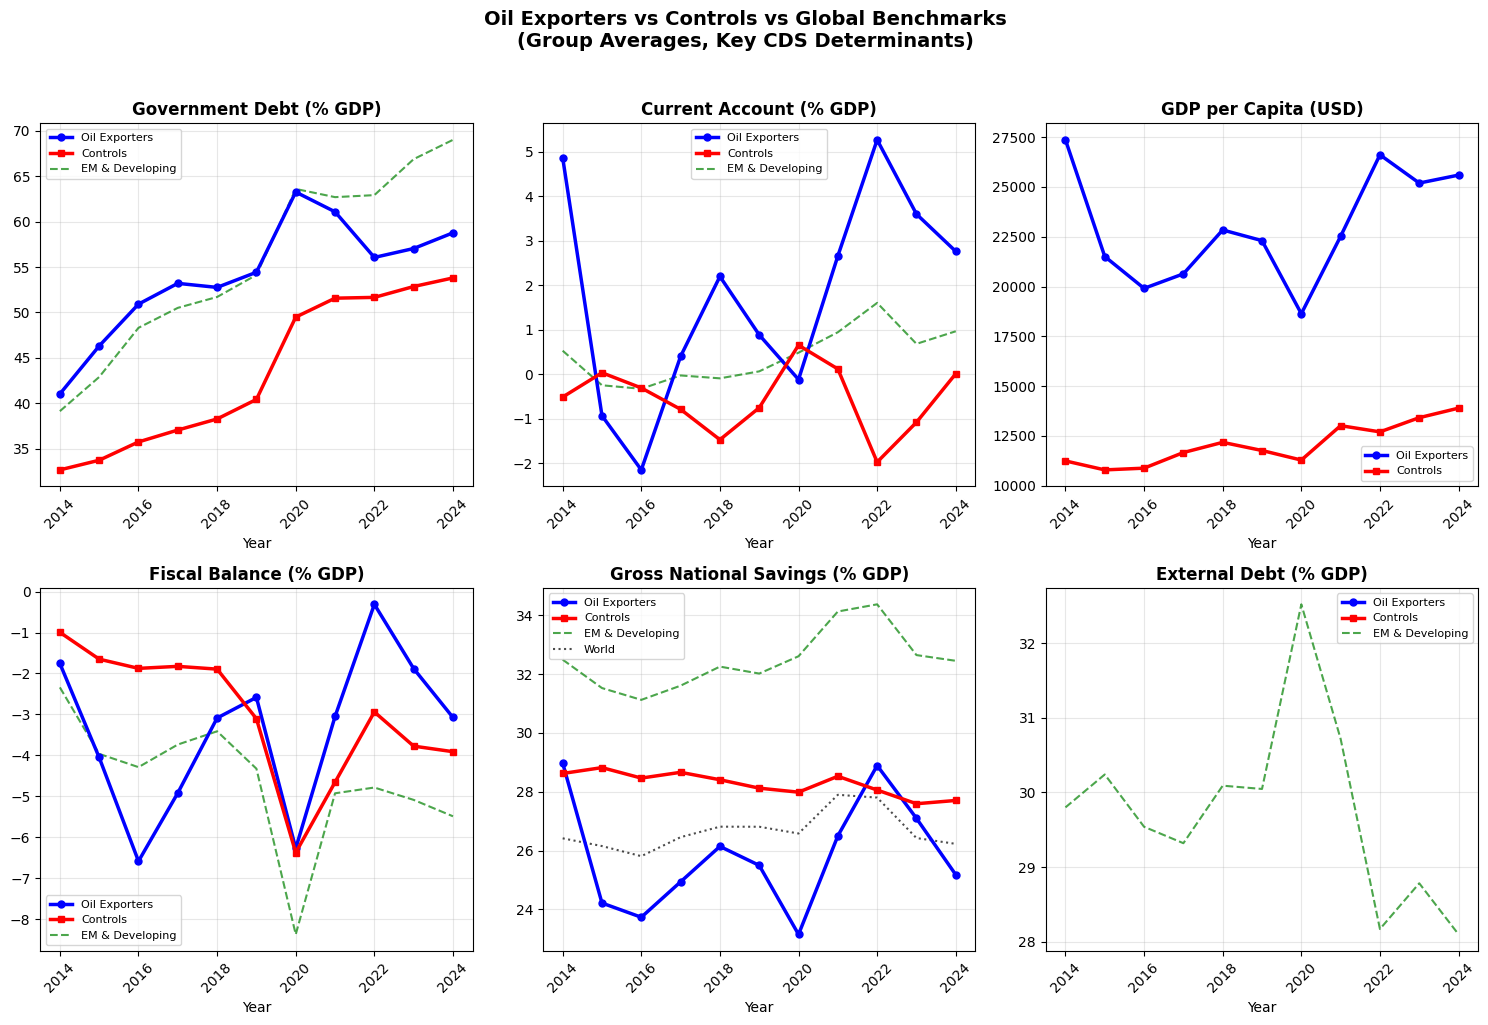

In [14]:
def compute_group_avg(df, countries, years):
    available = [c for c in countries if c in df.columns]
    subset = df.loc[df.index.isin(years), available]
    return subset.mean(axis=1)
def get_benchmark(df, benchmark_name, years):
    if benchmark_name in df.columns:
        return df.loc[df.index.isin(years), benchmark_name]
    return pd.Series(dtype=float)


# Create comparison plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(plot_vars):
    if var not in data_dict:
        axes[i].text(0.5, 0.5, f'{var}\nNot Available', ha='center', va='center')
        continue
    
    df = data_dict[var]
    
    # Compute group averages
    exp_avg = compute_group_avg(df, oil_exporters, year_range)
    ctrl_avg = compute_group_avg(df, controls, year_range)
    
    # Get benchmarks
    em_benchmark = get_benchmark(df, 'Emerging Market and Developing Economies', year_range)
    world_benchmark = get_benchmark(df, 'World', year_range)
    
    ax = axes[i]
    
    # Plot main groups (thick lines)
    ax.plot(exp_avg.index, exp_avg.values, 'b-o', label='Oil Exporters', 
            linewidth=2.5, markersize=5, zorder=5)
    ax.plot(ctrl_avg.index, ctrl_avg.values, 'r-s', label='Controls', 
            linewidth=2.5, markersize=5, zorder=5)
    
    # Plot benchmarks (thinner, dashed lines)
    if len(em_benchmark) > 0:
        ax.plot(em_benchmark.index, em_benchmark.values, 'g--', label='EM & Developing', 
                linewidth=1.5, alpha=0.7, zorder=3)
    if len(world_benchmark) > 0:
        ax.plot(world_benchmark.index, world_benchmark.values, 'k:', label='World', 
                linewidth=1.5, alpha=0.7, zorder=3)
    
    ax.set_title(var_labels.get(var, var), fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)
    
    # Rotate x-axis labels
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Oil Exporters vs Controls vs Global Benchmarks\n(Group Averages, Key CDS Determinants)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('group_comparison_with_benchmarks.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
all_countries = oil_exporters + controls

# Variables
variables = {
    'Gross debt - General government - Percent of GDP': 'Debt/GDP',
    'External debt - Percent of GDP': 'Ext Debt/GDP',
    'Current account balance (credit less debit) - Percent of GDP': 'CA/GDP',
    'Gross domestic product (GDP) - Current prices - Per capita - US dollar': 'GDP pc',
    'Net lending (+) / net borrowing (-) - General government - Percent of GDP': 'Fiscal Bal',
    'Gross national savings - Percent of GDP': 'Savings/GDP',
}

# Years to average
year_range = range(2014, 2025)

# Build table
table_data = {}

for indicator, short_name in variables.items():
    filtered = IMFWEO_data[IMFWEO_data['INDICATOR'] == indicator].drop(columns=['INDICATOR', 'FREQUENCY', 'SCALE'])
    filtered.set_index('COUNTRY', inplace=True)
    filtered = filtered.loc[filtered.index.isin(all_countries)]
    transposed = filtered.T
    transposed.index = transposed.index.astype(int)
    
    # Average over years
    avg = transposed.loc[transposed.index.isin(year_range)].mean()
    table_data[short_name] = avg

# Combine into single DataFrame
result = pd.DataFrame(table_data)

# Add group column
result['Group'] = result.index.map(lambda x: 'Exporter' if x in oil_exporters else 'Control')

# Reorder columns
result = result[['Group', 'Debt/GDP', 'Ext Debt/GDP', 'CA/GDP', 'GDP pc', 'Fiscal Bal', 'Savings/GDP']]

# Sort by group then country
result = result.sort_values(['Fiscal Bal'], ascending=[True])

result

,Group,Debt/GDP,Ext Debt/GDP,CA/GDP,GDP pc,Fiscal Bal,Savings/GDP
COUNTRY,,,,,,,
Egypt,Exporter,88.506364,NaN,-3.534000,3624.364091,-8.401091,14.315000
Brazil,Exporter,82.324909,NaN,-2.492818,9377.438909,-6.863727,14.285727
Saudi Arabia,Exporter,17.991909,NaN,2.599727,29292.108364,-5.774455,29.701273
China,Control,62.154455,NaN,1.687909,10572.019091,-5.170818,44.217000
South Africa,Control,59.041182,NaN,-1.462182,6434.089364,-5.053727,14.265000
Colombia,Exporter,54.860364,NaN,-4.280727,6724.743182,-4.370364,16.283909
Mexico,Exporter,53.596727,NaN,-1.063000,10721.679545,-3.520273,21.902727
Malaysia,Exporter,61.578636,NaN,2.909091,11064.190909,-3.477818,26.290455
Chile,Control,29.006909,NaN,-3.995818,14967.541364,-2.857818,19.958818


### Placebo classifications

Let's expand the 24 country list and build placebo classifications to see if oil effect persists.

In [ ]:
high_gdp_pc = ['Qatar','Abu Dhabi', 'Dubai','South Korea','Saudi Arabia','Chile','Turkey','Malaysia','Mexico','China']
low_gdp_pc = ['Philippines', 'Egypt','Indonesia','South Africa','Colombia','Brazil']

high_debt_to_gdp = ['Egypt','Brazil','China','Malaysia','South Africa','Colombia','Mexico','Qatar']
low_debt_to_gdp = ['Saudi Arabia','Abu Dhabi','Dubai','Chile','Turkey','Indonesia','South Korea','Philippines']

high_CA_to_GDP = ['Qatar','Abu Dhabi','Dubai','South Korea','Malaysia','Saudi Arabia', 'China','Philippines','Mexico']
low_CA_to_GDP = ['Colombia','Chile','Egypt','Brazil','Turkey','South Africa','Indonesia']

high_fiscal_bal = ['Qatar','Abu Dhabi','Dubai','South Korea']
low_fiscal_bal = ['Egypt','Brazil','Saudi Arabia','China','South Africa','Colombia','Mexico','Malaysia','Chile','Turkey','Indonesia','Philippines']

GCC_countries = ['Qatar','Abu Dhabi','Dubai','Saudi Arabia']
non_GCC_countries = ['Egypt','Brazil','South Korea','China','South Africa','Colombia','Mexico','Malaysia','Chile','Turkey','Indonesia','Philippines']

asian_countries = ['South Korea', 'Malaysia', 'China', 'Indonesia', 'Philippines', 'Thailand']
non_asian_countries = ['Qatar', 'Abu Dhabi', 'Dubai', 'Saudi Arabia', 'Egypt', 'Brazil', 'Colombia', 'Mexico', 'Chile', 'South Africa', 'Turkey']

latin_american_countries = ['Brazil', 'Colombia', 'Mexico', 'Chile']
non_latin_american_countries = ['Qatar', 'Abu Dhabi', 'Dubai', 'Saudi Arabia', 'Egypt', 'South Korea', 'Malaysia', 'China', 'Indonesia', 'Philippines', 'Thailand', 'South Africa', 'Turkey']

# Credit ratings (approximate, investment grade A- or better vs BBB+ or below)
high_credit_rating = ['Qatar', 'Abu Dhabi', 'Dubai', 'Saudi Arabia', 'South Korea', 'Chile', 'China', 'Malaysia']
low_credit_rating = ['Egypt', 'Brazil', 'Colombia', 'Mexico', 'Indonesia', 'Philippines', 'Turkey', 'South Africa', 'Thailand']

In [23]:
CDS_data = pd.read_csv('data/processed/CDS/Weekly_CDS.csv')
CDS_data['Date'] = pd.to_datetime(CDS_data['Date'])
CDS_data.set_index('Date', inplace=True)

Oil_data = pd.read_csv('data/processed/Oil/oil_prices_datastream.csv')
Oil_data['Date'] = pd.to_datetime(Oil_data['Date'])
Oil_data.set_index('Date', inplace=True)

Macro_risk_variables = pd.read_csv('data/processed/Macroeconomic_variables/macro_risk_variables.csv')
Macro_risk_variables['Date'] = pd.to_datetime(Macro_risk_variables['Date'])
Macro_risk_variables.set_index('Date', inplace=True)

VIX = pd.read_csv('data/processed/Macroeconomic_variables/VIXCLS.csv')
VIX['Date'] = pd.to_datetime(VIX['Date'])
VIX.set_index('Date', inplace=True)

OVX = pd.read_csv('data/processed/Macroeconomic_variables/OVXCLS.csv')
OVX['Date'] = pd.to_datetime(OVX['Date'])
OVX.set_index('Date', inplace=True)

# =============================================================================
# MERGE (WIDE FORMAT)
# =============================================================================

merged = CDS_data.copy()
merged = pd.merge(merged, Oil_data, left_index=True, right_index=True, how='inner')
merged = pd.merge(merged, Macro_risk_variables, left_index=True, right_index=True, how='inner')
merged = pd.merge(merged, VIX, left_index=True, right_index=True, how='inner')
merged = pd.merge(merged, OVX, left_index=True, right_index=True, how='inner')

# Filter date range
merged = merged[merged.index >= datetime.datetime(2014, 1, 1)].copy()
merged.reset_index(inplace=True)

# Oil returns (percent change)
merged['Oil_ret'] = merged['Brent'].pct_change()

# OVX change (percent change - it's a volatility index)
merged['OVX_chg'] = merged['OVXCLS'].pct_change()

# VIX change (percent change)
merged['VIX_chg'] = merged['VIXCLS'].pct_change()

# DXY change (percent change)
merged['DXY_chg'] = merged['DXY'].pct_change()

# Treasury change (diff change)
merged['UST2Y_chg'] = merged['UST2Y'].diff()
merged['UST5Y_chg'] = merged['UST5Y'].diff()
merged['UST10Y_chg'] = merged['UST10Y'].diff()


# Drop NA values from merged
#merged = merged.dropna().reset_index(drop=True)

# Check dimensions and range

print(f"\nMerged shape: {merged.shape}")
print(f"Date range: {merged['Date'].min()} to {merged['Date'].max()}")


# =============================================================================
# RESHAPE TO LONG FORMAT
# =============================================================================

oil_exporters = ['Saudi Arabia', 'Abu Dhabi', 'Dubai', 'Qatar', 'Colombia', 
                 'Mexico', 'Brazil', 'Egypt', 'Malaysia']
controls = ['Indonesia', 'Philippines', 'Turkey', 'Chile', 'China', 
            'South Africa', 'South Korea', 'Thailand']


global_vars = ['Date', 'Brent', 'Oil_ret', 'OVXCLS', 'OVX_chg', 
               'VIXCLS', 'VIX_chg', 'DXY_chg', 'UST2Y_chg', 'UST5Y_chg', 'UST10Y_chg']

merged = merged.reset_index()

panel_data = []

for country in oil_exporters + controls:
    if country not in merged.columns:
        print(f"Warning: {country} not in CDS data")
        continue
        
    temp = merged[global_vars + [country]].copy()
    temp['Country'] = country
    temp['CDS'] = temp[country]
    temp['OilExporter'] = 1 if country in oil_exporters else 0
    temp = temp.drop(columns=[country])
    panel_data.append(temp)

panel = pd.concat(panel_data, ignore_index=True)
panel = panel.sort_values(by=['Country', 'Date']).reset_index(drop=True)

# =============================================================================
# COMPUTE COUNTRY-SPECIFIC VARIABLES (CDS returns)
# =============================================================================

# CDS returns - THIS one needs groupby because it's country-specific
panel['CDS_ret'] = panel.groupby('Country')['CDS'].pct_change()

# Create interaction term
panel['OVX_x_Exporter'] = panel['OVX_chg'] * panel['OilExporter']
panel['Brent_chg_x_Exporter'] = panel['Oil_ret'] * panel['OilExporter']

# Drop NaN (first observation per country)
panel = panel.dropna(subset=['CDS_ret', 'OVX_chg', 'VIX_chg', 'DXY_chg', 'UST2Y_chg', 'UST5Y_chg', 'UST10Y_chg']).reset_index(drop=True)

panel.head()


Merged shape: (574, 91)
Date range: 2014-01-03 00:00:00 to 2024-12-27 00:00:00


/var/folders/wy/gjw_3_n51t748hfngpz4zf0w0000gn/T/ipykernel_40956/4123701362.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Oil_data['Date'] = pd.to_datetime(Oil_data['Date'])
/var/folders/wy/gjw_3_n51t748hfngpz4zf0w0000gn/T/ipykernel_40956/4123701362.py:10: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  Macro_risk_variables['Date'] = pd.to_datetime(Macro_risk_variables['Date'])


,Date,Brent,Oil_ret,OVXCLS,OVX_chg,VIXCLS,VIX_chg,DXY_chg,UST2Y_chg,UST5Y_chg,UST10Y_chg,Country,CDS,OilExporter,CDS_ret,OVX_x_Exporter,Brent_chg_x_Exporter
0,2014-01-10,106.33,-0.006911,19.47,-0.054854,12.14,-0.117733,-0.001609,-0.018,-0.103,-0.135,Abu Dhabi,55.85999,1,-0.008168,-0.054854,-0.006911
1,2014-01-17,106.89,0.005267,17.12,-0.120699,12.44,0.024712,0.007067,0.001,0.005,-0.033,Abu Dhabi,55.32999,1,-0.009488,-0.120699,0.005267
2,2014-01-24,107.45,0.005239,19.46,0.136682,18.14,0.458199,-0.009479,-0.031,-0.064,-0.092,Abu Dhabi,55.34999,1,0.000361,0.136682,0.005239
3,2014-01-31,107.13,-0.002978,20.35,0.045735,18.41,0.014884,0.010564,-0.008,-0.056,-0.069,Abu Dhabi,56.32999,1,0.017706,0.045735,-0.002978
4,2014-02-07,108.21,0.010081,19.03,-0.064865,15.29,-0.169473,-0.007625,-0.033,-0.048,0.009,Abu Dhabi,56.32999,1,0.000000,-0.064865,0.010081


In [26]:
from linearmodels.panel import PanelOLS
import pandas as pd
import numpy as np

# =============================================================================
# DEFINE ALL CLASSIFICATIONS
# =============================================================================

classifications = {
    'Oil Exporters': {
        'treatment': ['Saudi Arabia', 'Abu Dhabi', 'Dubai', 'Qatar', 'Colombia', 'Mexico', 'Brazil', 'Egypt', 'Malaysia'],
        'control': ['Indonesia', 'Philippines', 'Turkey', 'Chile', 'China', 'South Africa', 'South Korea', 'Thailand']
    },
    'GCC': {
        'treatment': ['Qatar', 'Abu Dhabi', 'Dubai', 'Saudi Arabia'],
        'control': ['Egypt', 'Brazil', 'South Korea', 'China', 'South Africa', 'Colombia', 'Mexico', 'Malaysia', 'Chile', 'Turkey', 'Indonesia', 'Philippines', 'Thailand']
    },
    'Low GDP pc': {
        'control': ['Qatar', 'Abu Dhabi', 'Dubai', 'South Korea', 'Saudi Arabia', 'Chile', 'Turkey', 'Malaysia', 'Mexico', 'China'],
        'treatment': ['Philippines', 'Egypt', 'Indonesia', 'South Africa', 'Colombia', 'Brazil', 'Thailand']
    },
    'High Debt/GDP': {
        'treatment': ['Egypt', 'Brazil', 'China', 'Malaysia', 'South Africa', 'Colombia', 'Mexico', 'Qatar'],
        'control': ['Saudi Arabia', 'Abu Dhabi', 'Dubai', 'Chile', 'Turkey', 'Indonesia', 'South Korea', 'Philippines', 'Thailand']
    },
    'Low CA/GDP': {
        'control': ['Qatar', 'Abu Dhabi', 'Dubai', 'South Korea', 'Malaysia', 'Saudi Arabia', 'China', 'Philippines', 'Mexico'],
        'treatment': ['Colombia', 'Chile', 'Egypt', 'Brazil', 'Turkey', 'South Africa', 'Indonesia', 'Thailand']
    },
    'Low Fiscal Bal': {
        'control': ['Qatar', 'Abu Dhabi', 'Dubai', 'South Korea'],
        'treatment': ['Egypt', 'Brazil', 'Saudi Arabia', 'China', 'South Africa', 'Colombia', 'Mexico', 'Malaysia', 'Chile', 'Turkey', 'Indonesia', 'Philippines', 'Thailand']
    },
    'Asian': {
        'treatment': ['South Korea', 'Malaysia', 'China', 'Indonesia', 'Philippines', 'Thailand'],
        'control': ['Qatar', 'Abu Dhabi', 'Dubai', 'Saudi Arabia', 'Egypt', 'Brazil', 'Colombia', 'Mexico', 'Chile', 'South Africa', 'Turkey']
    },
    'Latin America': {
        'treatment': ['Brazil', 'Colombia', 'Mexico', 'Chile'],
        'control': ['Qatar', 'Abu Dhabi', 'Dubai', 'Saudi Arabia', 'Egypt', 'South Korea', 'Malaysia', 'China', 'Indonesia', 'Philippines', 'Thailand', 'South Africa', 'Turkey']
    },
    'Low Credit Rating': {
        'control': ['Qatar', 'Abu Dhabi', 'Dubai', 'Saudi Arabia', 'South Korea', 'Chile', 'China', 'Malaysia'],
        'treatment': ['Egypt', 'Brazil', 'Colombia', 'Mexico', 'Indonesia', 'Philippines', 'Turkey', 'South Africa', 'Thailand']
    },
}

# Thresholds to test
thresholds = [1.0, 0.10, 0.05, 0.01]  # 1.0 = full sample

# =============================================================================
# RUN ALL REGRESSIONS
# =============================================================================

results_list = []

for class_name, groups in classifications.items():
    
    treatment = groups['treatment']
    control = groups['control']
    
    # Create classification-specific panel
    temp_panel = panel.copy()
    temp_panel['Treatment'] = temp_panel['Country'].isin(treatment).astype(int)
    temp_panel['OVX_x_Treatment'] = temp_panel['OVX_chg'] * temp_panel['Treatment']
    
    for pct in thresholds:
        
        # Filter to threshold
        if pct == 1.0:
            subset = temp_panel.copy()
            threshold_label = 'Full'
        else:
            oil_qtl = temp_panel['OVX_chg'].quantile(1 - pct)
            subset = temp_panel[temp_panel['OVX_chg'] > oil_qtl].copy()
            threshold_label = f'Top {pct*100:.0f}%'
        
        # Skip if too few observations
        if len(subset) < 50:
            continue
        
        # Prepare for linearmodels
        subset['Date'] = pd.to_datetime(subset['Date'])
        reg_data = subset.set_index(['Country', 'Date'])
        
        y = reg_data['CDS_ret']
        
        # Model A: Country FE + explicit controls
        try:
            X_a = reg_data[['OVX_chg', 'OVX_x_Treatment', 'VIX_chg', 'DXY_chg', 'UST10Y_chg']]
            model_a = PanelOLS(y, X_a, entity_effects=True, time_effects=False, drop_absorbed=True)
            res_a = model_a.fit(cov_type='clustered', cluster_entity=True)
            beta_a = res_a.params['OVX_x_Treatment']
            pval_a = res_a.pvalues['OVX_x_Treatment']
        except:
            beta_a, pval_a = np.nan, np.nan
        
        # Model B: Country FE + Time FE
        try:
            X_b = reg_data[['OVX_x_Treatment']]
            model_b = PanelOLS(y, X_b, entity_effects=True, time_effects=True, drop_absorbed=True)
            res_b = model_b.fit(cov_type='clustered', cluster_entity=True)
            beta_b = res_b.params['OVX_x_Treatment']
            pval_b = res_b.pvalues['OVX_x_Treatment']
        except:
            beta_b, pval_b = np.nan, np.nan
        
        results_list.append({
            'Classification': class_name,
            'Threshold': threshold_label,
            'N': len(subset),
            'N_treatment': subset['Treatment'].sum(),
            'N_control': len(subset) - subset['Treatment'].sum(),
            'Beta_A': beta_a,
            'pval_A': pval_a,
            'Beta_B': beta_b,
            'pval_B': pval_b,
        })

# =============================================================================
# CREATE RESULTS DATAFRAME
# =============================================================================

results_df = pd.DataFrame(results_list)

# =============================================================================
# PRINT RESULTS - MODEL A
# =============================================================================

print("="*90)
print("MODEL A: Country FE + Global Controls (VIX, DXY, UST10Y)")
print("="*90)

# Pivot for easier reading
pivot_a = results_df.pivot(index='Classification', columns='Threshold', values='Beta_A')
pivot_a = pivot_a[['Full', 'Top 10%', 'Top 5%', 'Top 1%']]  # Order columns

pivot_pval_a = results_df.pivot(index='Classification', columns='Threshold', values='pval_A')
pivot_pval_a = pivot_pval_a[['Full', 'Top 10%', 'Top 5%', 'Top 1%']]

# Print with significance stars
print(f"\n{'Classification':<20} {'Full':>12} {'Top 10%':>12} {'Top 5%':>12} {'Top 1%':>12}")
print("-"*70)

for idx in pivot_a.index:
    row_str = f"{idx:<20}"
    for col in pivot_a.columns:
        beta = pivot_a.loc[idx, col]
        pval = pivot_pval_a.loc[idx, col]
        
        if pd.isna(beta):
            row_str += f"{'N/A':>12}"
        else:
            sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
            row_str += f"{beta:>10.3f}{sig:<2}"
    print(row_str)

print("\n* p<0.1, ** p<0.05, *** p<0.01")

# =============================================================================
# PRINT RESULTS - MODEL B
# =============================================================================

print("\n" + "="*90)
print("MODEL B: Country FE + Time FE")
print("="*90)

pivot_b = results_df.pivot(index='Classification', columns='Threshold', values='Beta_B')
pivot_b = pivot_b[['Full', 'Top 10%', 'Top 5%', 'Top 1%']]

pivot_pval_b = results_df.pivot(index='Classification', columns='Threshold', values='pval_B')
pivot_pval_b = pivot_pval_b[['Full', 'Top 10%', 'Top 5%', 'Top 1%']]

print(f"\n{'Classification':<20} {'Full':>12} {'Top 10%':>12} {'Top 5%':>12} {'Top 1%':>12}")
print("-"*70)

for idx in pivot_b.index:
    row_str = f"{idx:<20}"
    for col in pivot_b.columns:
        beta = pivot_b.loc[idx, col]
        pval = pivot_pval_b.loc[idx, col]
        
        if pd.isna(beta):
            row_str += f"{'N/A':>12}"
        else:
            sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
            row_str += f"{beta:>10.3f}{sig:<2}"
    print(row_str)

print("\n* p<0.1, ** p<0.05, *** p<0.01")

# =============================================================================
# HIGHLIGHT: COMPARE OIL EXPORTERS VS OTHER CLASSIFICATIONS
# =============================================================================

print("\n" + "="*90)
print("COMPARISON: Oil Exporters vs Placebo Classifications (Top 10% OVX, Model A)")
print("="*90)

top10_results = results_df[results_df['Threshold'] == 'Top 10%'].copy()
top10_results = top10_results.sort_values('Beta_A', ascending=False)

print(f"\n{'Classification':<20} {'Beta':>10} {'p-value':>10} {'Significant':>12}")
print("-"*55)

for _, row in top10_results.iterrows():
    sig = '***' if row['pval_A'] < 0.01 else '**' if row['pval_A'] < 0.05 else '*' if row['pval_A'] < 0.1 else ''
    is_sig = 'Yes' if row['pval_A'] < 0.05 else 'No'
    print(f"{row['Classification']:<20} {row['Beta_A']:>10.3f} {row['pval_A']:>10.3f} {is_sig:>10} {sig}")

MODEL A: Country FE + Global Controls (VIX, DXY, UST10Y)

Classification               Full      Top 10%       Top 5%       Top 1%
----------------------------------------------------------------------
Asian                    0.015      -0.021       0.027       0.477  
GCC                     -0.040*     -0.004      -0.088       0.100  
High Debt/GDP            0.041       0.078       0.115       0.308  
Latin America            0.083***     0.140***     0.173**    -0.201  
Low CA/GDP              -0.002      -0.016      -0.006      -0.683**
Low Credit Rating        0.018       0.038       0.087      -0.309  
Low Fiscal Bal           0.042**     0.042       0.107*      0.104  
Low GDP pc               0.021       0.051       0.091      -0.114  
Oil Exporters            0.025       0.141***     0.147**     0.608* 

* p<0.1, ** p<0.05, *** p<0.01

MODEL B: Country FE + Time FE

Classification               Full      Top 10%       Top 5%       Top 1%
-------------------------------------